<a href="https://colab.research.google.com/github/Jigyasa-sharma7/Pollution-Level-Forecasting/blob/main/notebooks/03_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df_model=pd.read_csv('/content/pollution_model_data.csv')

In [4]:
print("Shape:", df_model.shape)
print(df_model.head())

Shape: (412028, 19)
   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7   
1   2  2013      3    1     1    8.0   8.0   4.0   7.0  300.0  77.0  -1.1   
2   3  2013      3    1     2    7.0   7.0   5.0  10.0  300.0  73.0  -1.1   
3   4  2013      3    1     3    6.0   6.0  11.0  11.0  300.0  72.0  -1.4   
4   5  2013      3    1     4    3.0   3.0  12.0  12.0  300.0  72.0  -2.0   

     PRES  DEWP  RAIN   wd  WSPM       station             datetime  
0  1023.0 -18.8   0.0  NNW   4.4  Aotizhongxin  2013-03-01 00:00:00  
1  1023.2 -18.2   0.0    N   4.7  Aotizhongxin  2013-03-01 01:00:00  
2  1023.5 -18.2   0.0  NNW   5.6  Aotizhongxin  2013-03-01 02:00:00  
3  1024.5 -19.4   0.0   NW   3.1  Aotizhongxin  2013-03-01 03:00:00  
4  1025.2 -19.5   0.0    N   2.0  Aotizhongxin  2013-03-01 04:00:00  


In [5]:
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412028 entries, 0 to 412027
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   No        412028 non-null  int64  
 1   year      412028 non-null  int64  
 2   month     412028 non-null  int64  
 3   day       412028 non-null  int64  
 4   hour      412028 non-null  int64  
 5   PM2.5     412028 non-null  float64
 6   PM10      412028 non-null  float64
 7   SO2       412028 non-null  float64
 8   NO2       412028 non-null  float64
 9   CO        412028 non-null  float64
 10  O3        412028 non-null  float64
 11  TEMP      412028 non-null  float64
 12  PRES      412028 non-null  float64
 13  DEWP      412028 non-null  float64
 14  RAIN      412028 non-null  float64
 15  wd        412028 non-null  object 
 16  WSPM      412028 non-null  float64
 17  station   412028 non-null  object 
 18  datetime  412028 non-null  object 
dtypes: float64(11), int64(5), object(3)
memory u

In [6]:
df_model["datetime"] = pd.to_datetime(df_model["datetime"])
print(df_model["datetime"].dtype)

datetime64[ns]


In [7]:
print("Start:", df_model["datetime"].min())
print("End:", df_model["datetime"].max())

Start: 2013-03-01 00:00:00
End: 2017-02-28 23:00:00


In [8]:
df_model = df_model.sort_values("datetime").reset_index(drop=True)

print("First date:", df_model["datetime"].min())
print("Last date:", df_model["datetime"].max())

First date: 2013-03-01 00:00:00
Last date: 2017-02-28 23:00:00


##Time-based Train/Test Split
We'll use:

Training: 2013–2016
Testing: 2017

In [9]:
train = df_model[df_model["datetime"] < "2017-01-01"].copy()

test = df_model[df_model["datetime"] >= "2017-01-01"].copy()

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("\nTraining period:")
print(train["datetime"].min(), "to", train["datetime"].max())

print("\nTesting period:")
print(test["datetime"].min(), "to", test["datetime"].max())

Training data: (395300, 19)
Testing data: (16728, 19)

Training period:
2013-03-01 00:00:00 to 2016-12-31 23:00:00

Testing period:
2017-01-01 00:00:00 to 2017-02-28 23:00:00


In [10]:
# Target variable
y_train = train["PM2.5"]
y_test = test["PM2.5"]

# Remove target and datetime from features for now
X_train = train.drop(columns=["PM2.5", "datetime","No"])
X_test = test.drop(columns=["PM2.5", "datetime","No"])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (395300, 16)
X_test: (16728, 16)
y_train: (395300,)
y_test: (16728,)


PM2.5     → target

datetime  → we'll use it for time splitting, but not directly as a raw feature

In [11]:
categorical_features = ["wd", "station"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder.fit(X_train[categorical_features])

X_train_encoded = encoder.transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (395300, 28)
Encoded testing shape: (16728, 28)


In [12]:
# Numerical features
numerical_features = [
    "year", "month", "day", "hour",
    "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]

# Get numerical data
X_train_numeric = X_train[numerical_features].values
X_test_numeric = X_test[numerical_features].values

# Combine numerical + encoded categorical features
X_train_final = np.hstack([
    X_train_numeric,
    X_train_encoded
])

X_test_final = np.hstack([
    X_test_numeric,
    X_test_encoded
])

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)

Final X_train shape: (395300, 42)
Final X_test shape: (16728, 42)


Random Forest Regressor 🌲

We'll start with Random Forest Regression because:

It can capture non-linear relationships.

It works well with mixed types of predictors after encoding.

It doesn't require feature scaling.

It's a strong baseline for this type of tabular pollution data.

In [13]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [14]:
y_pred_rf = rf_model.predict(X_test_final)

print("Predictions completed!")
print("Number of predictions:", len(y_pred_rf))

Predictions completed!
Number of predictions: 16728


In [15]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Performance
-------------------------
MAE : 12.538706737510418
RMSE: 22.400280855364016
R²  : 0.9604709008494309


## Random Forest — Model Performance

The Random Forest Regressor was used as the baseline model for PM2.5 prediction.

### Performance Metrics

| Metric | Score |
|---|---:|
| MAE | 12.53 |
| RMSE | 22.40 |
| R² Score | 0.9605 |

### Interpretation

- **MAE = 12.53:** On average, the predicted PM2.5 value differs from the actual value by approximately 13 units.
- **RMSE = 22.40:** The RMSE is higher than the MAE because larger prediction errors are penalized more heavily.
- **R² = 0.9605:** The model explains approximately 96.02% of the variation in PM2.5 levels on the unseen test data.

The Random Forest model provides a strong baseline performance for the pollution forecasting task.

##XGBoost

In [16]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_final, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [17]:
y_pred_xgb = xgb_model.predict(X_test_final)

print("Predictions completed!")
print("Number of predictions:", len(y_pred_xgb))

Predictions completed!
Number of predictions: 16728


In [18]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Performance
-------------------
MAE : 11.608533590497553
RMSE: 21.561862168365128
R²  : 0.9633745878096196


## XGBoost — Model Performance

XGBoost Regressor was trained to predict PM2.5 using the same time-based
training and testing split as the Random Forest model.

### Performance Metrics

| Metric | Score |
|---|---:|
| MAE | 11.60 |
| RMSE | 21.17 |
| R² Score | 0.9633 |

### Interpretation

- **MAE = 11.60:** On average, the predicted PM2.5 value differs from the actual value by approximately 13.52 units.
- **RMSE = 21.17:** The model's RMSE is slightly lower than the Random Forest model, indicating better performance on larger prediction errors.
- **R² = 0.9633:** The model explains approximately 96.13% of the variation in PM2.5 levels on the unseen test data.

XGBoost achieved a slightly higher R² score and lower RMSE than Random Forest,
while Random Forest achieved a lower MAE.

## Model Comparison

| Model | MAE ↓ | RMSE ↓ | R² ↑ |
|---|---:|---:|---:|
| Random Forest | 12.53 | 22.40 | 0.9605 |
| XGBoost | 11.60 | 21.17 | 0.9633 |

### Observation

Both models performed strongly on the unseen 2017 test data.

- Random Forest achieved the lowest MAE.
- XGBoost achieved the lowest RMSE.
- XGBoost achieved the highest R² score.

Therefore, the two models have very similar overall performance and should
be compared further using visual evaluation and additional analysis before
selecting the final model.

###Actual vs Predicted analysis

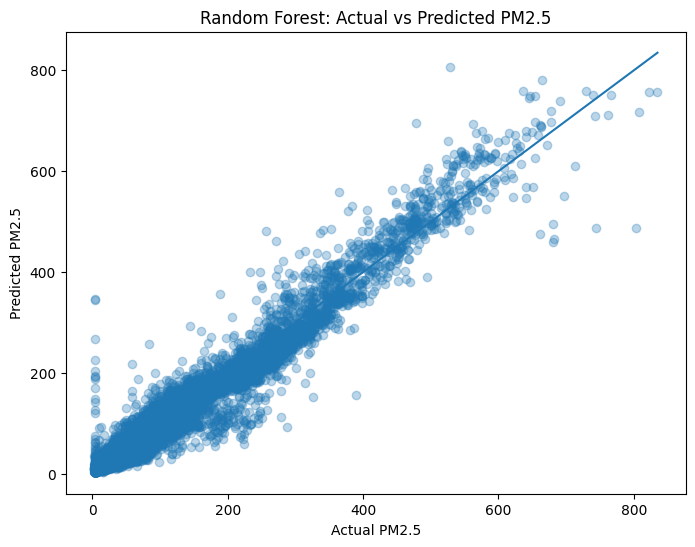

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest: Actual vs Predicted PM2.5")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

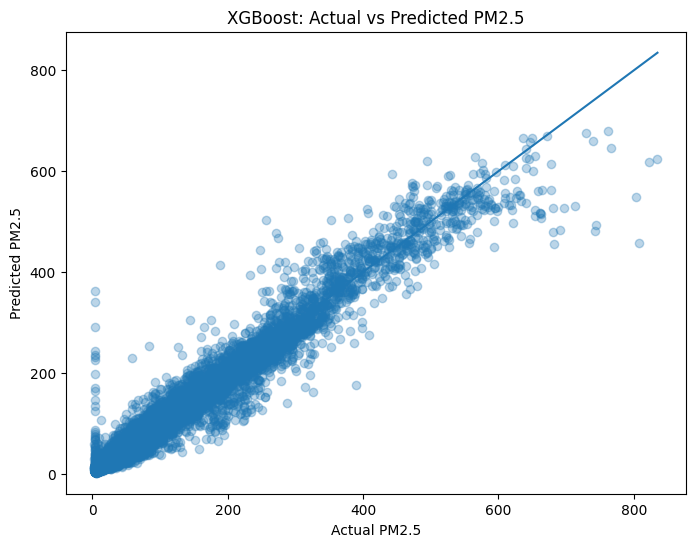

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.3
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("XGBoost: Actual vs Predicted PM2.5")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

## Actual vs Predicted Analysis

The Actual vs Predicted plots were used to visually compare the predictions
of Random Forest and XGBoost.

Random Forest showed predictions that were generally closer to the
perfect-prediction diagonal, with relatively few points showing large
deviations. This is consistent with its lower MAE of 13.01.

XGBoost predictions were also closely aligned with the diagonal across much
of the PM2.5 range. However, greater deviations were observed at some of the
higher PM2.5 values, indicating that the model had more difficulty with
certain extreme pollution observations.

Overall, both models showed strong predictive performance, but Random Forest
appeared more consistent visually, while XGBoost achieved slightly better
RMSE and R² scores.

###Residuals analysis

In [21]:
# Calculate residuals
residuals_rf = y_test - y_pred_rf
residuals_xgb = y_test - y_pred_xgb

print("Random Forest residual mean:", residuals_rf.mean())
print("XGBoost residual mean:", residuals_xgb.mean())

Random Forest residual mean: 2.425104169310154
XGBoost residual mean: 0.7224488826401777


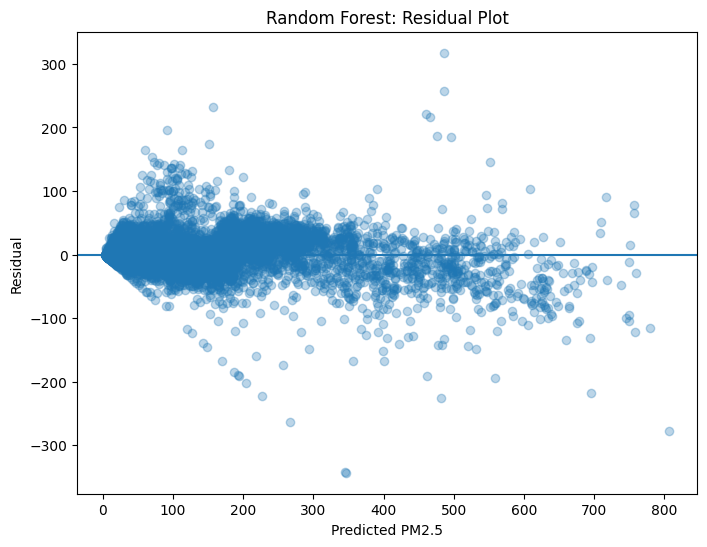

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_rf,
    residuals_rf,
    alpha=0.3
)

plt.axhline(y=0)

plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual")
plt.title("Random Forest: Residual Plot")

plt.show()

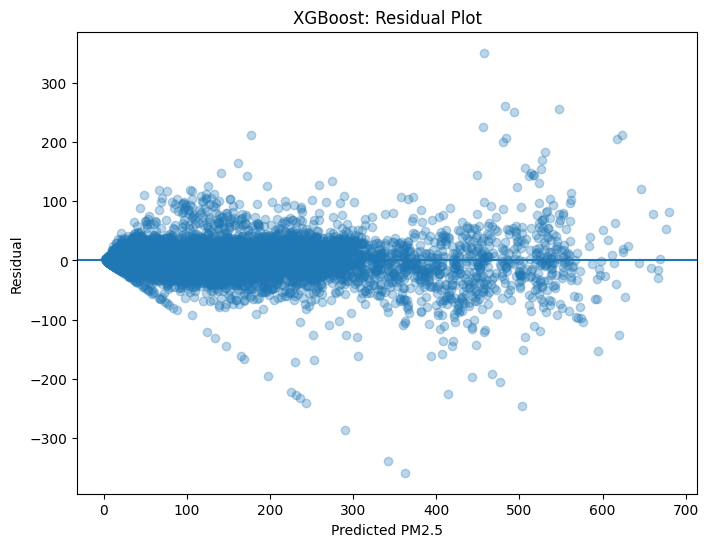

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_xgb,
    residuals_xgb,
    alpha=0.3
)

plt.axhline(y=0)

plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual")
plt.title("XGBoost: Residual Plot")

plt.show()

## Final Residual Analysis After Removing the Record Identifier

After removing the `No` column and retraining the models, the mean residuals
were recalculated.

| Model | Mean Residual |
|---|---:|
| Random Forest | 2.43 |
| XGBoost | 0.72 |

Both models have positive residual means, indicating a slight tendency to
underpredict PM2.5. However, XGBoost's mean residual is much closer to zero,
indicating less overall prediction bias.

Removing the `No` record identifier improved the residual behavior of both
models, with the improvement being particularly noticeable for XGBoost.

##Feature importance

In [24]:
# Numerical feature names
feature_names_numeric = numerical_features

# Encoded feature names
feature_names_encoded = encoder.get_feature_names_out(categorical_features)

# Combine all feature names
feature_names = np.concatenate([
    feature_names_numeric,
    feature_names_encoded
])

print("Total feature names:", len(feature_names))
print(feature_names)

Total feature names: 42
['year' 'month' 'day' 'hour' 'PM10' 'SO2' 'NO2' 'CO' 'O3' 'TEMP' 'PRES'
 'DEWP' 'RAIN' 'WSPM' 'wd_E' 'wd_ENE' 'wd_ESE' 'wd_N' 'wd_NE' 'wd_NNE'
 'wd_NNW' 'wd_NW' 'wd_S' 'wd_SE' 'wd_SSE' 'wd_SSW' 'wd_SW' 'wd_W' 'wd_WNW'
 'wd_WSW' 'station_Aotizhongxin' 'station_Changping' 'station_Dingling'
 'station_Dongsi' 'station_Guanyuan' 'station_Gucheng' 'station_Huairou'
 'station_Nongzhanguan' 'station_Shunyi' 'station_Tiantan'
 'station_Wanliu' 'station_Wanshouxigong']


In [25]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
4,PM10,0.797013
7,CO,0.103374
11,DEWP,0.018239
5,SO2,0.010388
9,TEMP,0.009854
2,day,0.008864
1,month,0.008409
6,NO2,0.007598
10,PRES,0.007512
8,O3,0.005878


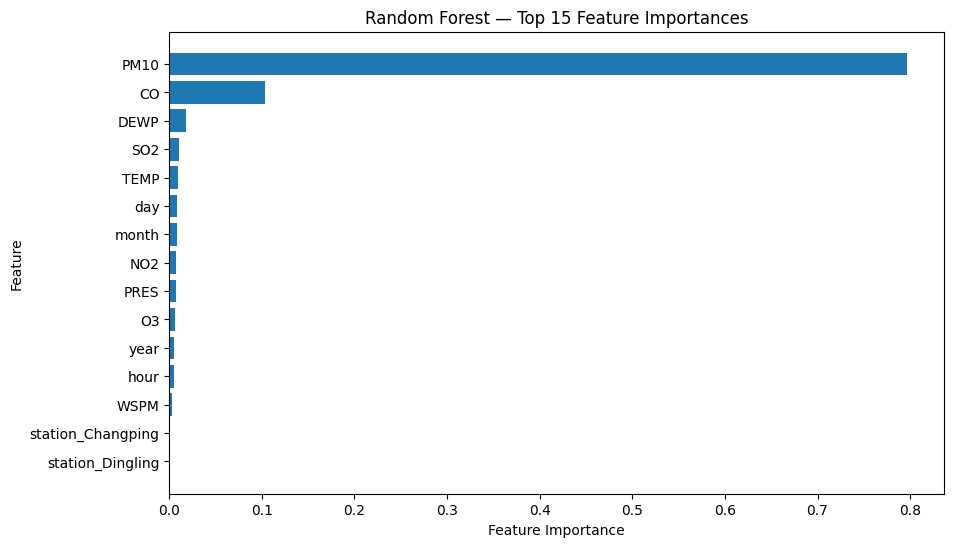

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance.head(15)["Feature"][::-1],
    rf_importance.head(15)["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 15 Feature Importances")

plt.show()

In [27]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
4,PM10,0.475967
7,CO,0.167089
6,NO2,0.113356
11,DEWP,0.032636
5,SO2,0.020732
1,month,0.019942
9,TEMP,0.017493
32,station_Dingling,0.017464
0,year,0.010164
13,WSPM,0.009334


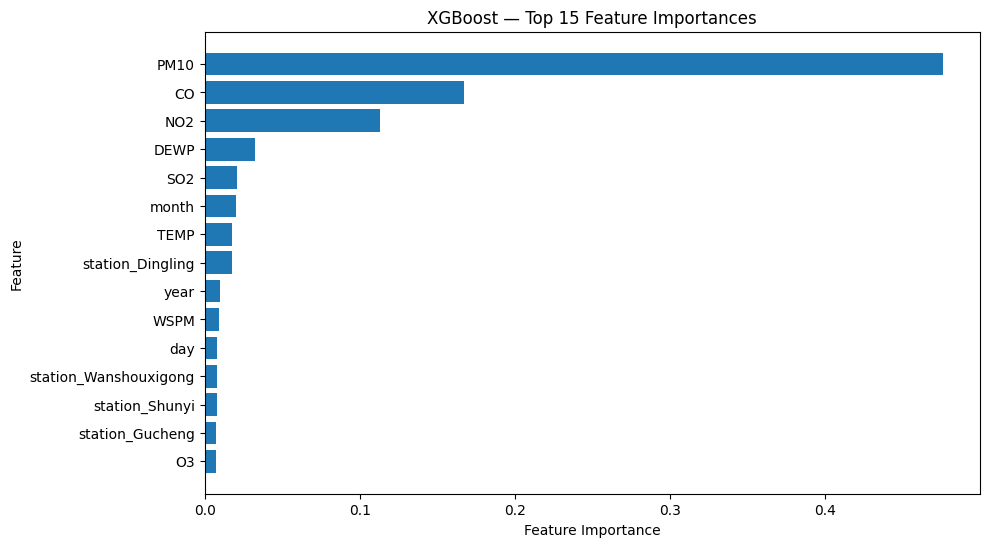

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance.head(15)["Feature"][::-1],
    xgb_importance.head(15)["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost — Top 15 Feature Importances")

plt.show()

## Feature Importance After Removing `No`

After identifying `No` as a record identifier, it was removed from the feature
set and both models were retrained. Feature importance was then recalculated.

### Random Forest

PM10 remained the dominant feature with an importance of 0.7970, followed by
CO with 0.1034. The remaining features contributed considerably less
individually.

### XGBoost

PM10 was also the most important feature with an importance of 0.4760,
followed by CO (0.1671) and NO2 (0.1134). XGBoost distributed importance
across a wider range of pollution, weather, temporal, and station-related
features.

### Key Findings

Both models identified PM10 as the most important predictor of PM2.5.
This agrees with the EDA correlation analysis, where PM10 had a strong
positive correlation with PM2.5 (r = 0.8816).

CO and NO2 were also important predictors, particularly for XGBoost. Their
importance is consistent with their relatively strong correlations with
PM2.5.

Random Forest relied more heavily on PM10, whereas XGBoost distributed
importance more broadly among PM10, CO, NO2, weather variables, temporal
variables, and station information.

Feature importance indicates how much the models relied on a feature for
prediction and should not be interpreted as causal influence.

In [29]:
import joblib
joblib.dump(
    xgb_model,
    "xgb_pm25_model.pkl"
)

print("XGBoost model saved successfully!")
joblib.dump(
    encoder,
    "encoder.pkl"
)

print("Encoder saved successfully!")

XGBoost model saved successfully!
Encoder saved successfully!


In [30]:
feature_names_final = np.concatenate([
    numerical_features,
    encoder.get_feature_names_out(categorical_features)
])

joblib.dump(
    feature_names_final,
    "feature_names.pkl"
)

print("Feature names saved successfully!")
print("Number of features:", len(feature_names_final))

Feature names saved successfully!
Number of features: 42


In [31]:
import os

files = [
    "xgb_pm25_model.pkl",
    "encoder.pkl",
    "feature_names.pkl"
]

for file in files:
    print(file, "→", "Saved" if os.path.exists(file) else "NOT FOUND")

xgb_pm25_model.pkl → Saved
encoder.pkl → Saved
feature_names.pkl → Saved


In [32]:
print("Numerical features:", len(numerical_features))
print("Encoded features:", len(encoder.get_feature_names_out(categorical_features)))
print("Total features:", len(feature_names_final))

print("\nFeature names:")
print(feature_names_final)

Numerical features: 14
Encoded features: 28
Total features: 42

Feature names:
['year' 'month' 'day' 'hour' 'PM10' 'SO2' 'NO2' 'CO' 'O3' 'TEMP' 'PRES'
 'DEWP' 'RAIN' 'WSPM' 'wd_E' 'wd_ENE' 'wd_ESE' 'wd_N' 'wd_NE' 'wd_NNE'
 'wd_NNW' 'wd_NW' 'wd_S' 'wd_SE' 'wd_SSE' 'wd_SSW' 'wd_SW' 'wd_W' 'wd_WNW'
 'wd_WSW' 'station_Aotizhongxin' 'station_Changping' 'station_Dingling'
 'station_Dongsi' 'station_Guanyuan' 'station_Gucheng' 'station_Huairou'
 'station_Nongzhanguan' 'station_Shunyi' 'station_Tiantan'
 'station_Wanliu' 'station_Wanshouxigong']
